# 02 — Search Landscapes & Geometry-Guided Search

Reproduces paper **Fig. 1** (`geo_limited_search_improvement.png`),
**Fig. 3** (`landscape_comparison_gemma3.png`), **Fig. 9**
(`TPE_vs_grid_search.png` in Appendix §F).

All inputs come from `results/optuna/` (TPE trial histories per seed and
search mode) and `results/steering_evaluations/` (the §3 grid-sweep CSVs).


In [17]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Ensure working directory is the repo root so relative paths resolve correctly.
_repo_root = Path(__file__).resolve().parent.parent if '__file__' in dir() else Path.cwd()
if (_repo_root / 'grace').is_dir():
    os.chdir(_repo_root)
elif (_repo_root.parent / 'grace').is_dir():
    os.chdir(_repo_root.parent)

from grace.analysis.load_results import load_optuna_history, load_summary_results
from grace.analysis.t95 import t95

FIG_DIR = Path('Images'); FIG_DIR.mkdir(exist_ok=True)
GEMMA3 = 'google/gemma-3-27b-it'
CONCEPTS = sorted(p.stem for p in Path('concepts/gpt-5/extract').glob('*.json'))

# ── Plotting style ──────────────────────────────────────────────────────────
sns.set_style("whitegrid")
plt.rcParams.update({
    "figure.dpi": 200,
    "savefig.dpi": 300,
    "font.size": 14,
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "figure.titleweight": "bold",
})

print(f"CWD: {Path.cwd()}")
print(f"Concepts: {len(CONCEPTS)}")

CWD: /home/jtr2875/GRACE
Concepts: 20


## Fig. 3 — Landscape contrast: broad vs. narrow optimum (Gemma3)

Two example concepts — one with a broad, forgiving landscape (e.g. `professional`)
and one with a narrow, sharp peak (e.g. `golden_gate_centric`). Each panel is
the (layer × coef) heatmap of mean utility from the §3 grid sweep.


In [ ]:
concepts = ['professional', 'golden_gate_centric']
TARGET_LAYERS = [22, 25, 26, 27, 29, 30, 32, 35, 37, 38, 40, 42, 45, 47, 50, 52, 55, 58]
TARGET_COEFS = [2.0, 3.0, 4.0]

# Load unit-mean evaluations filtered to the target grid
dfs = {}
for concept in concepts:
    rows = load_summary_results(GEMMA3, concept, method='unit_mean')
    df = pd.DataFrame(rows)
    dfs[concept] = df[(df['layer'].isin(TARGET_LAYERS)) & (df['coef'].isin(TARGET_COEFS))]

# Compute shared color scale
all_steerability = pd.concat([d['mean_utility'].dropna() for d in dfs.values()])
vmin = all_steerability.min()
vmax = all_steerability.max()
margin = (vmax - vmin) * 0.05
vmin = max(0, vmin - margin)
vmax = min(100, vmax + margin)

fig, axes = plt.subplots(len(concepts), 1,
                         figsize=(max(len(TARGET_LAYERS) * 0.9, 14), len(concepts) * 4),
                         sharex=True)

for idx, concept in enumerate(concepts):
    ax = axes[idx]
    df = dfs[concept]
    pivot = df.pivot_table(index='coef', columns='layer', values='mean_utility')
    pivot = pivot.reindex(index=TARGET_COEFS, columns=TARGET_LAYERS)

    sns.heatmap(
        pivot, ax=ax, cmap='YlOrRd',
        vmin=vmin, vmax=vmax,
        annot=True, fmt='.0f', annot_kws={'size': 12, 'weight': 'bold'},
        linewidths=0.5, linecolor='white',
        cbar_kws={'label': 'Steerability', 'shrink': 0.6, 'pad': 0.02},
        mask=pivot.isna(),
    )

    # Gray out missing cells
    for i in range(len(TARGET_COEFS)):
        for j in range(len(TARGET_LAYERS)):
            if pd.isna(pivot.iloc[i, j]):
                ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=True,
                             facecolor='#e0e0e0', edgecolor='white', linewidth=0.5))

    # Outline the best cell
    if len(df) > 0:
        best_row = df.loc[df['mean_utility'].idxmax()]
        best_layer_pos = TARGET_LAYERS.index(int(best_row['layer']))
        best_coef_pos = TARGET_COEFS.index(best_row['coef'])
        ax.add_patch(plt.Rectangle(
            (best_layer_pos, best_coef_pos), 1, 1,
            fill=False, edgecolor='black', linewidth=2.5,
        ))
        best_str = (f"  |  Best: layer {int(best_row['layer'])}, "
                    f"coef {best_row['coef']:.1f} \u2192 {best_row['mean_utility']:.1f}")
    else:
        best_str = ""

    ax.set_ylabel('Coefficient', fontsize=15, fontweight='bold')
    ax.set_title(f'{concept}{best_str}', fontsize=16, fontweight='bold')
    if idx == len(concepts) - 1:
        ax.set_xlabel('Layer', fontsize=15, fontweight='bold')
    else:
        ax.set_xlabel('')

fig.suptitle('Steerability Heatmap (Gemma 3 27B, Unit Mean)',
             fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig(FIG_DIR / 'landscape_comparison_gemma3.png', dpi=300, bbox_inches='tight')
plt.show()

## Fig. 1 — Geometry-restricted TPE vs. unconstrained TPE

Mean best-found-utility as a function of trial number, averaged across the
20 concepts on Gemma3-27B and the 3 seeds. Two curves: `unconstrained` (full
layer range) vs. `top15_pl` (alignment-restricted). Convergence is faster on
the alignment-restricted variant (paper's 44.5 % T95 reduction).


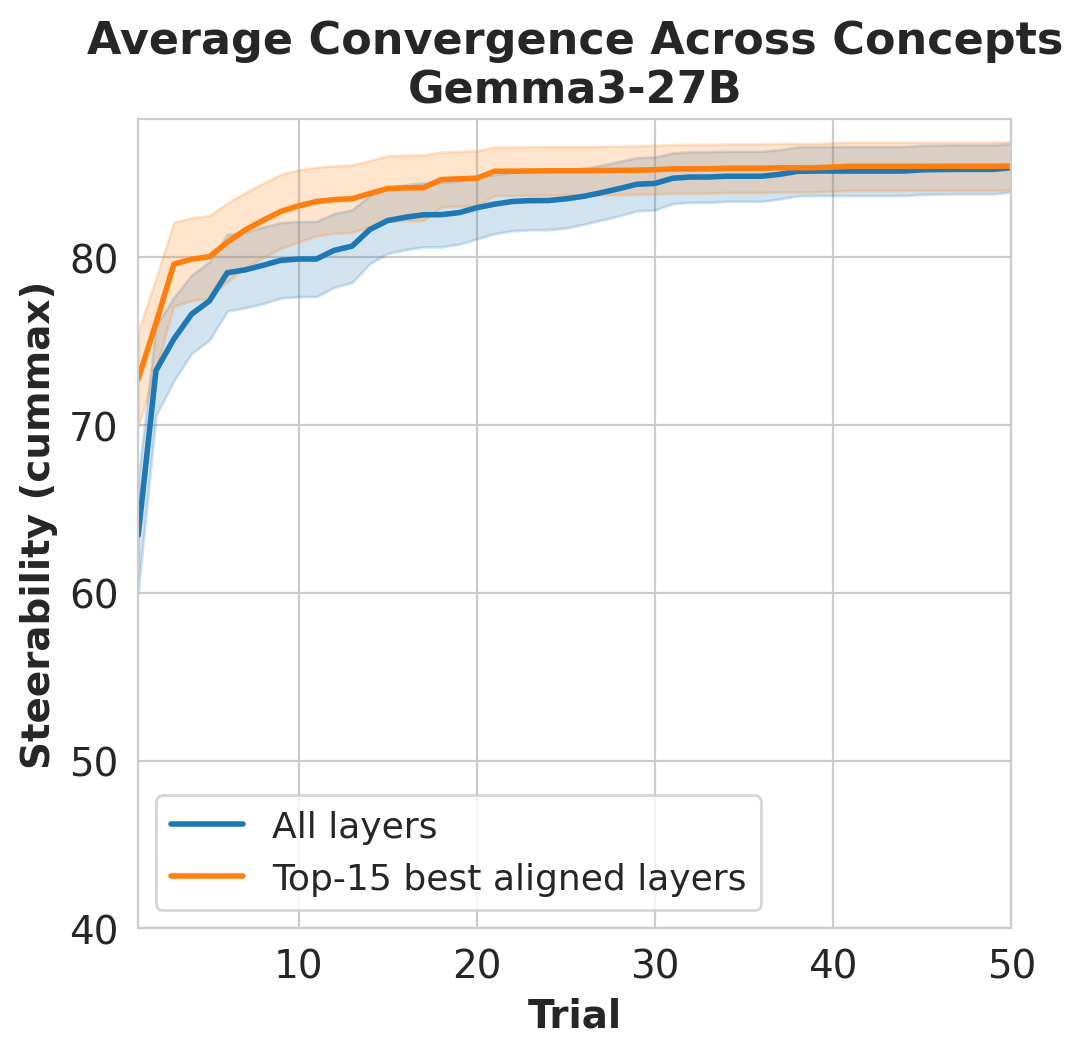

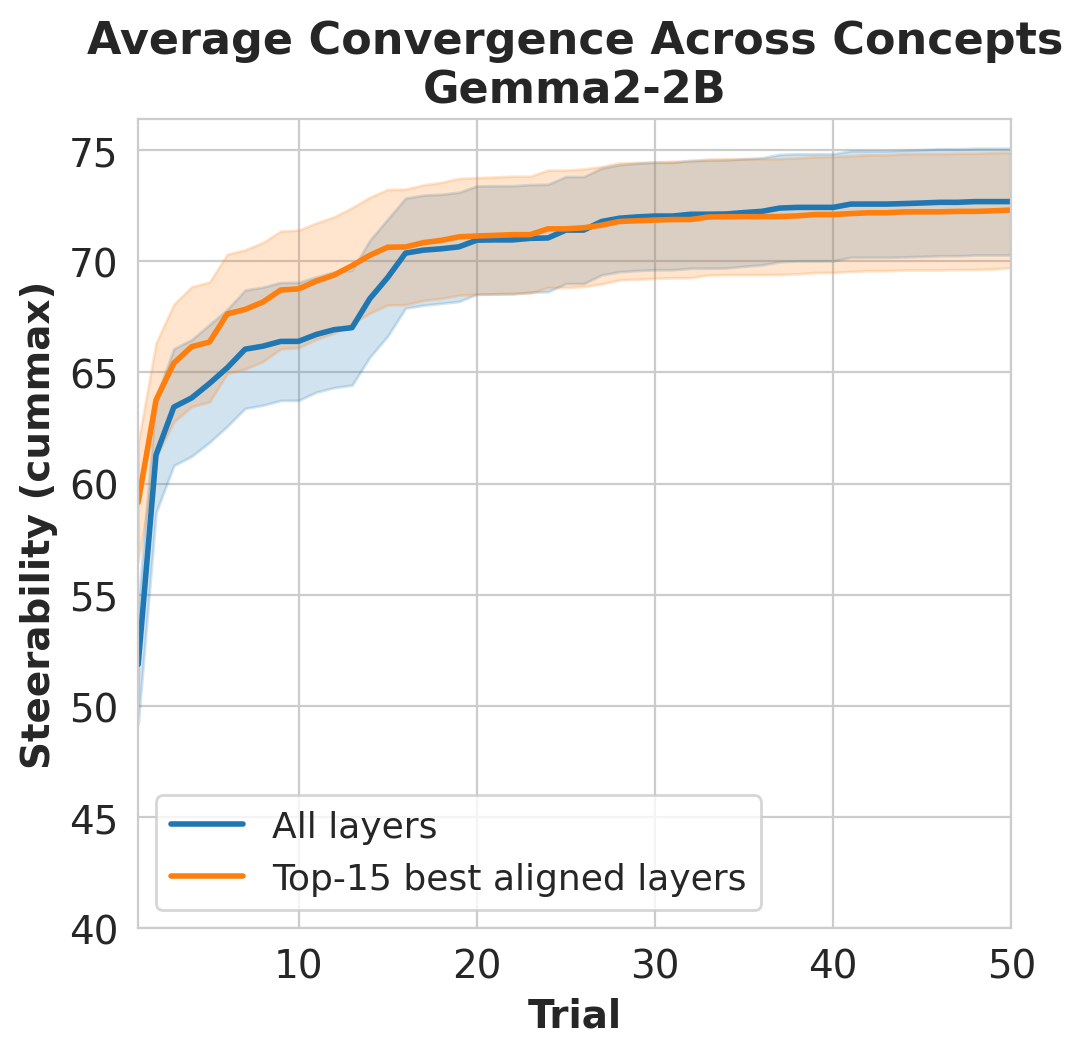

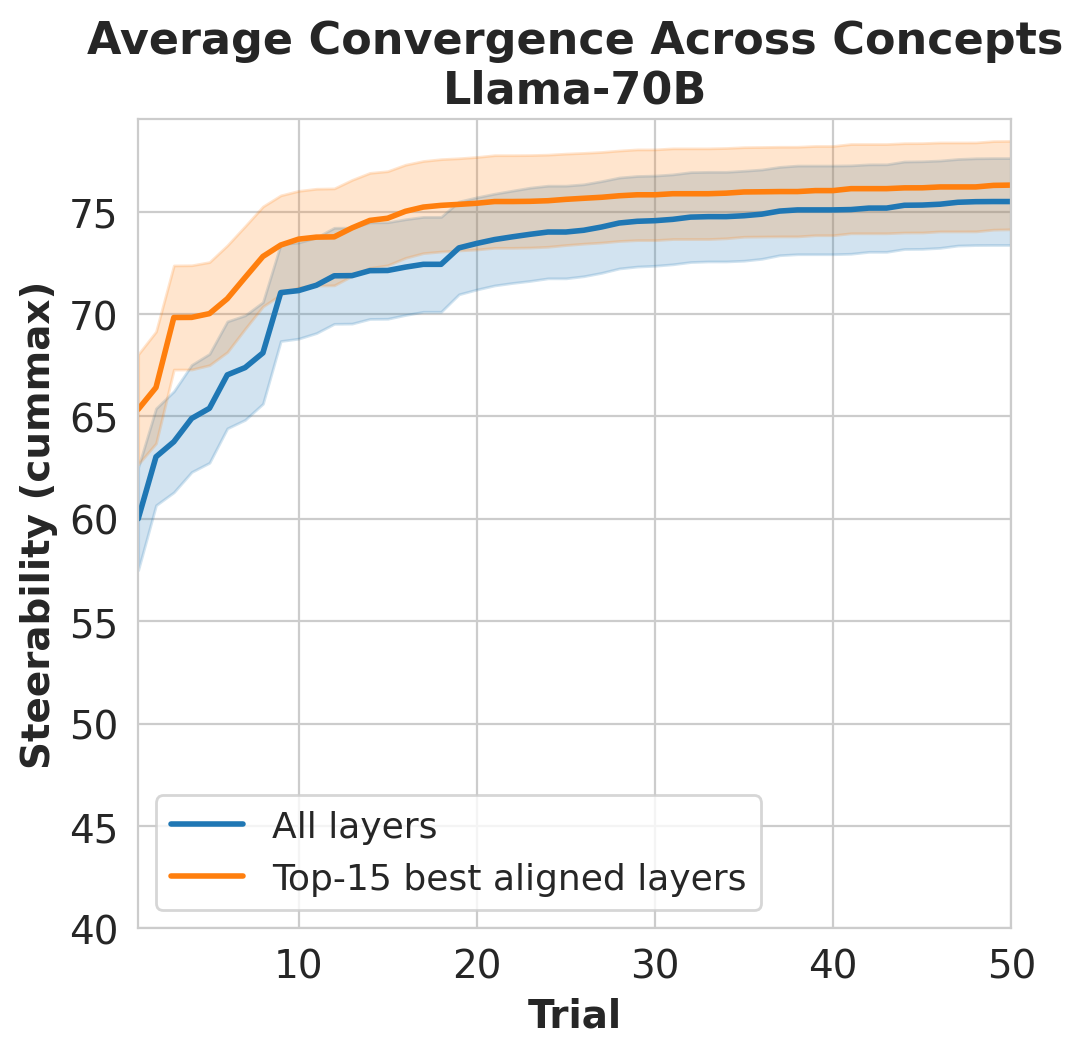

In [19]:
MODELS = {
    'gemma3': ('google/gemma-3-27b-it', 'Gemma3-27B'),
    'gemma2': ('google/gemma-2-2b-it', 'Gemma2-2B'),
    'llama3': ('meta-llama/Llama-3.3-70B-Instruct', 'Llama-70B'),
}
N_TRIALS = 50

def mean_best_curve(model_name, concepts, mode):
    """Compute mean best-value-so-far across concepts, padded to N_TRIALS."""
    all_curves = []
    for c in concepts:
        rows = load_optuna_history(model_name, c, method='pv', mode=mode)
        if not rows:
            continue
        df = pd.DataFrame(rows)
        seed_curves = []
        for seed in df['seed'].unique():
            sdf = df[df['seed'] == seed].sort_values('trial')
            bv = sdf['best_value_so_far'].values
            if len(bv) < N_TRIALS:
                bv = np.concatenate([bv, np.full(N_TRIALS - len(bv), bv[-1])])
            else:
                bv = bv[:N_TRIALS]
            seed_curves.append(bv)
        if seed_curves:
            all_curves.append(np.mean(seed_curves, axis=0))
    if not all_curves:
        return np.array([]), np.array([]), np.array([])
    stacked = np.array(all_curves)
    mean = np.mean(stacked, axis=0)
    stderr = np.std(stacked, axis=0) / np.sqrt(len(stacked))
    x = np.arange(1, N_TRIALS + 1)
    return x, mean, stderr

for model_tag, (model_name, model_short) in MODELS.items():
    fig, ax = plt.subplots(figsize=(5.5, 5.5))

    for search_label, mode, color in [
        ('All layers', 'unconstrained', 'tab:blue'),
        ('Top-15 best aligned layers', 'top15_pl', 'tab:orange'),
    ]:
        x, mean, stderr = mean_best_curve(model_name, CONCEPTS, mode)
        if len(x) == 0:
            continue
        ax.plot(x, mean, color=color, linewidth=2, label=search_label)
        ax.fill_between(x, mean - stderr, mean + stderr, color=color, alpha=0.2)

    ax.set_xlim(1, N_TRIALS)
    ax.set_ylim(bottom=40)
    ax.set_xlabel('Trial')
    ax.set_ylabel('Steerability (cummax)')
    ax.set_title(f'Average Convergence Across Concepts\n{model_short}',
                 fontsize=16, fontweight='bold')
    ax.legend(fontsize=13)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f'geo_limited_search_improvement_{model_tag}.png',
                dpi=300, bbox_inches='tight')
    plt.show()

    # Also save the gemma3 version under the paper's expected filename
    if model_tag == 'gemma3':
        fig.savefig(FIG_DIR / 'geo_limited_search_improvement.png',
                    dpi=300, bbox_inches='tight')

## Fig. 9 — TPE vs. fixed-interval grid search

TPE typically beats the §3 grid sweep within ~15 trials. We compute the
best-utility curve for unconstrained TPE and overlay the grid-search result
as a horizontal line per concept (averaged).


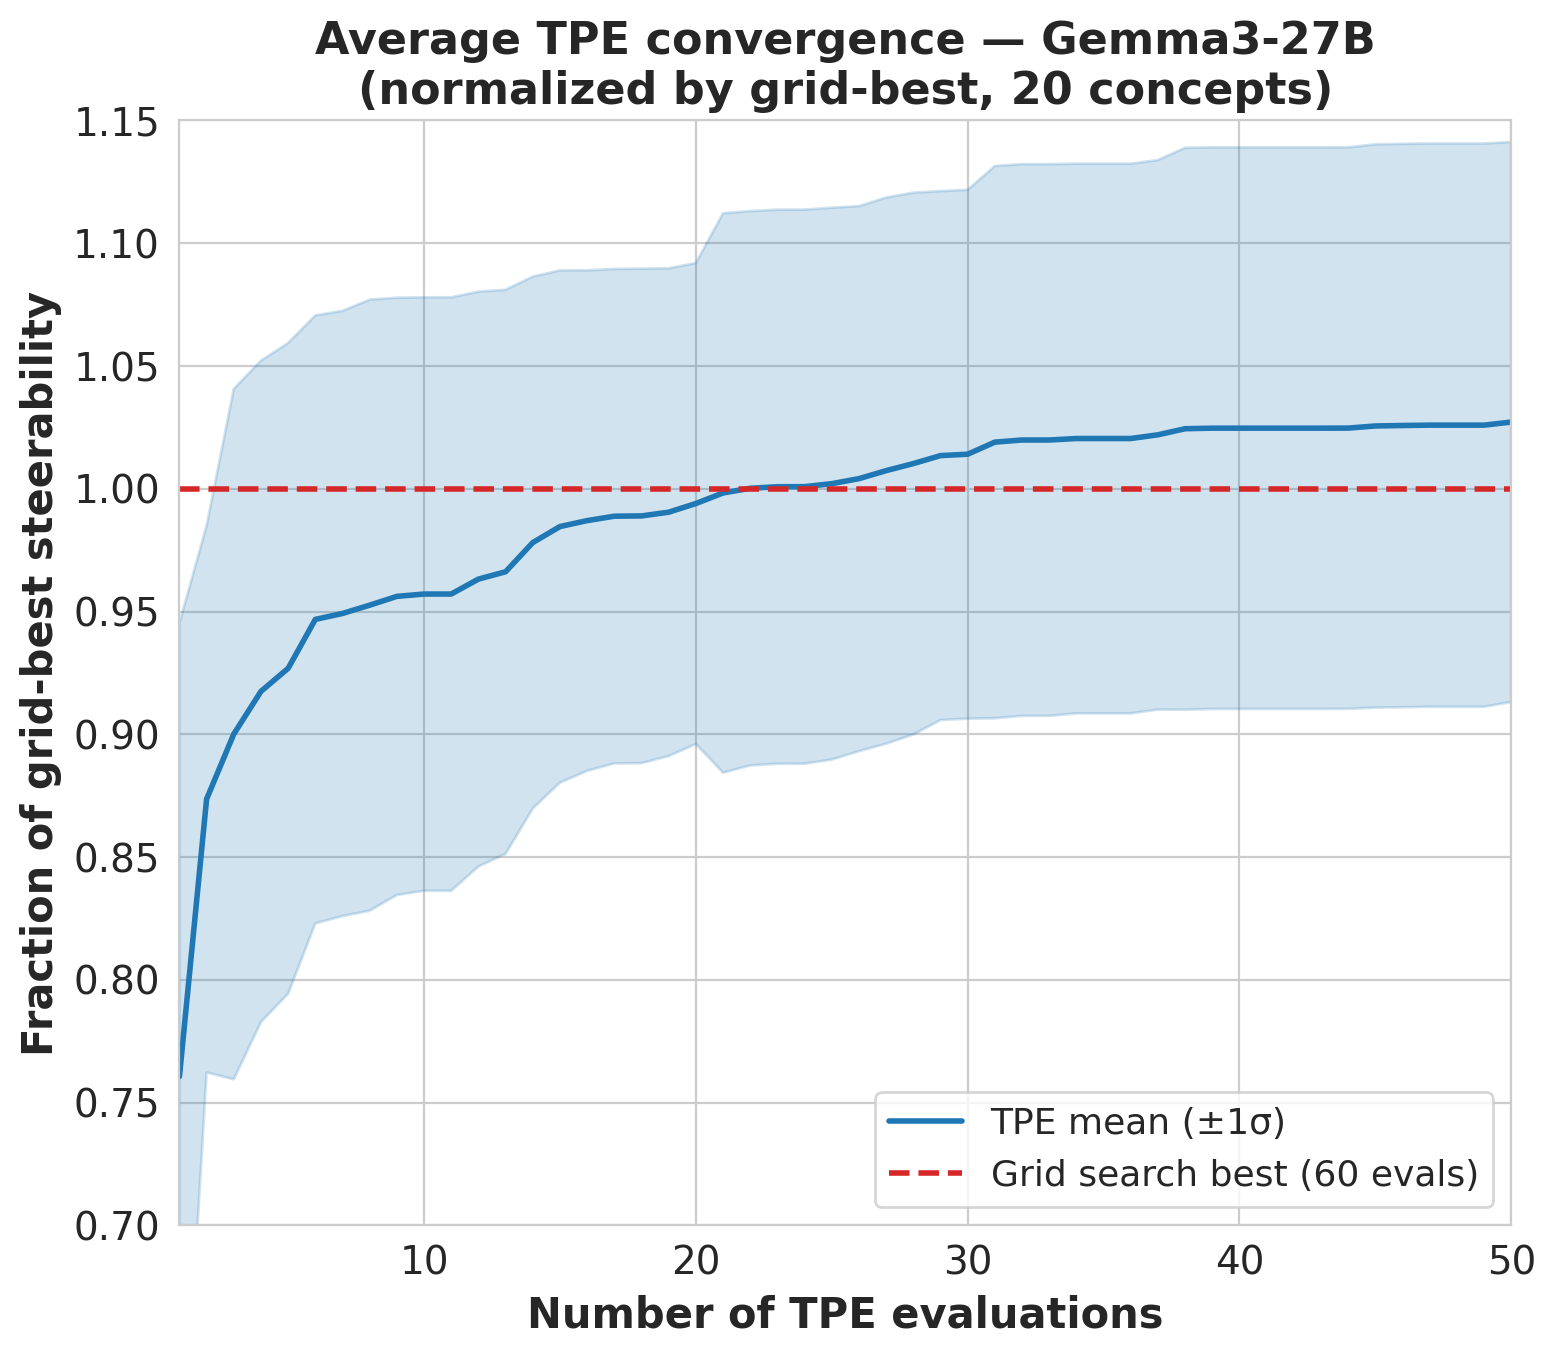

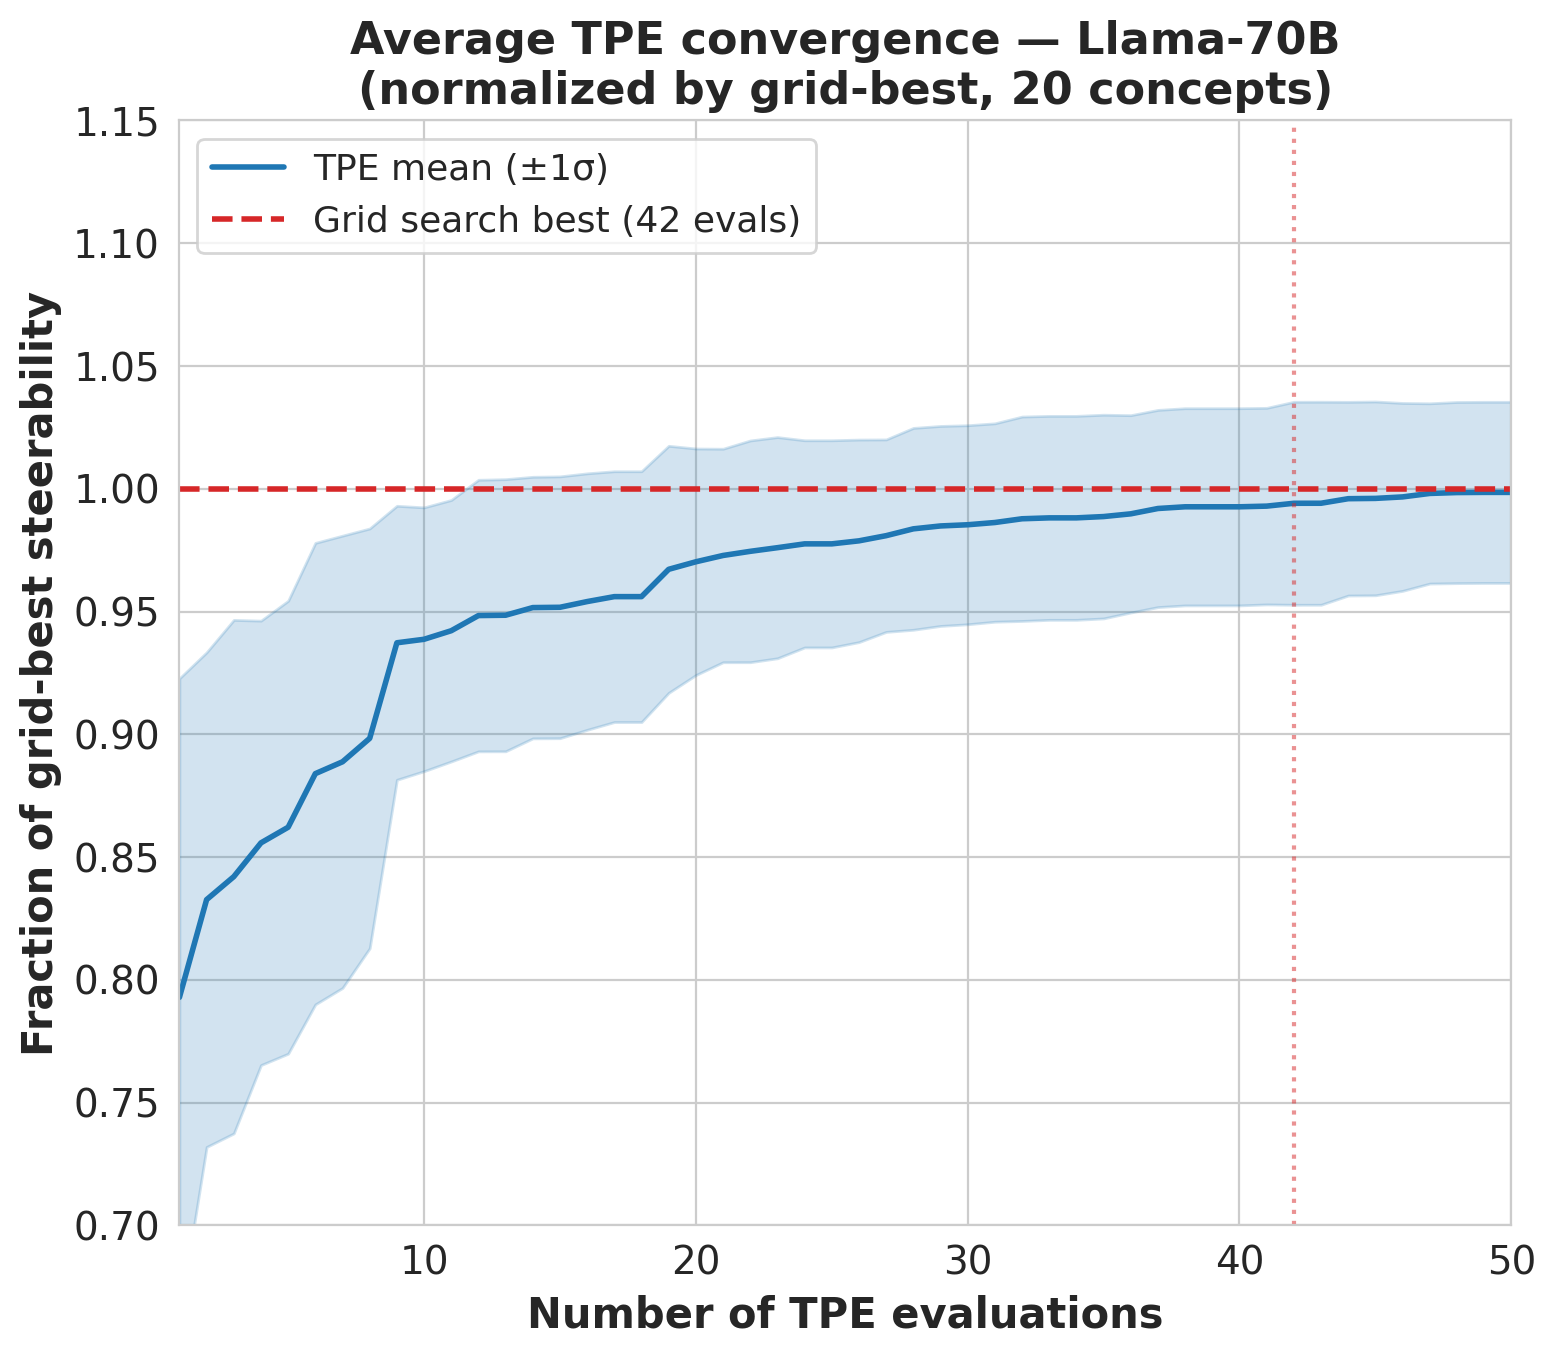

In [20]:
GRID_CONFIGS = {
    'gemma3': {
        'model_name': 'google/gemma-3-27b-it',
        'short': 'Gemma3-27B',
        'layers': [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60],
        'coefs': [0.5, 1.0, 1.5, 2.0, 3.0],
    },
    'llama3': {
        'model_name': 'meta-llama/Llama-3.3-70B-Instruct',
        'short': 'Llama-70B',
        'layers': [10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75],
        'coefs': [1.0, 2.0, 3.0],
    },
}

for model_tag, cfg in GRID_CONFIGS.items():
    model_name = cfg['model_name']
    grid_layers = cfg['layers']
    grid_coefs = cfg['coefs']
    n_grid_evals = len(grid_layers) * len(grid_coefs)

    # Compute grid-best per concept (filtered to fixed sweep points only)
    grid_best = {}
    for c in CONCEPTS:
        rows = load_summary_results(model_name, c, method='pv')
        if not rows:
            continue
        sweep_rows = [r for r in rows
                      if r['layer'] in grid_layers and r['coef'] in grid_coefs
                      and r.get('mean_utility') is not None]
        if sweep_rows:
            grid_best[c] = max(r['mean_utility'] for r in sweep_rows)

    # Compute TPE normalized convergence curves
    all_curves = []
    for c in CONCEPTS:
        if c not in grid_best:
            continue
        gb = grid_best[c]
        hist_rows = load_optuna_history(model_name, c, method='pv', mode='unconstrained')
        if not hist_rows:
            continue
        df = pd.DataFrame(hist_rows)
        for seed in df['seed'].unique():
            sdf = df[df['seed'] == seed].sort_values('trial')
            bv = sdf['best_value_so_far'].values
            normalized = bv / gb
            all_curves.append(normalized)

    if not all_curves:
        print(f'{cfg["short"]}: no TPE data')
        continue

    # Pad to same length
    max_len = max(len(c) for c in all_curves)
    padded = np.full((len(all_curves), max_len), np.nan)
    for i, c in enumerate(all_curves):
        padded[i, :len(c)] = c

    mean_curve = np.nanmean(padded, axis=0)
    std_curve = np.nanstd(padded, axis=0)
    trials = np.arange(1, max_len + 1)

    fig, ax = plt.subplots(figsize=(8, 7))
    ax.fill_between(trials, mean_curve - std_curve, mean_curve + std_curve,
                    alpha=0.2, color='C0')
    ax.plot(trials, mean_curve, color='C0', linewidth=2, label='TPE mean (\u00b11\u03c3)')
    ax.axhline(1.0, color='C3', linestyle='--', linewidth=2,
               label=f'Grid search best ({n_grid_evals} evals)')
    ax.axvline(n_grid_evals, color='C3', linestyle=':', alpha=0.5, linewidth=1.5)

    ax.set_xlabel('Number of TPE evaluations', fontsize=15, fontweight='bold')
    ax.set_ylabel('Fraction of grid-best steerability', fontsize=15, fontweight='bold')
    ax.set_title(f'Average TPE convergence — {cfg["short"]}\n'
                 f'(normalized by grid-best, {len(grid_best)} concepts)',
                 fontsize=16, fontweight='bold')
    ax.legend(fontsize=13)
    ax.set_xlim(1, 50)
    ax.set_ylim(0.7, 1.15)
    plt.tight_layout()
    fig.savefig(FIG_DIR / f'TPE_vs_grid_search_{model_tag}.png',
                dpi=300, bbox_inches='tight')
    plt.show()

    if model_tag == 'gemma3':
        fig.savefig(FIG_DIR / 'TPE_vs_grid_search.png',
                    dpi=300, bbox_inches='tight')